In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS

In [2]:
tickers = {
    "ADANIENT": "ADANIENT.NS",
    "ADANIPORTS": "ADANIPORTS.NS",
    "APOLLOHOSP": "APOLLOHOSP.NS",
    "ASIANPAINT": "ASIANPAINT.NS",
    "AXISBANK": "AXISBANK.NS",
    "BAJAJ_AUTO": "BAJAJ-AUTO.NS",
    "BAJAJFINSV": "BAJAJFINSV.NS",
    "BAJFINANCE": "BAJFINANCE.NS",
    "BEL": "BEL.NS",
    "BHARTIARTL": "BHARTIARTL.NS",
    "CIPLA": "CIPLA.NS",
    "COALINDIA": "COALINDIA.NS",
    "DRREDDY": "DRREDDY.NS",
    "EICHERMOT": "EICHERMOT.NS",
    "ETERNAL": "ETERNAL.NS",
    "GRASIM": "GRASIM.NS",
    "HCLTECH": "HCLTECH.NS",
    "HDFCBANK": "HDFCBANK.NS",
    "HDFCLIFE": "HDFCLIFE.NS",
    "HINDALCO": "HINDALCO.NS",
    "HINDUNILVR": "HINDUNILVR.NS",
    "ICICIBANK": "ICICIBANK.NS",
    "INDIGO": "INDIGO.NS",
    "INFY": "INFY.NS",
    "ITC": "ITC.NS",
    "JIOFIN": "JIOFIN.NS",
    "JSWSTEEL": "JSWSTEEL.NS",
    "KOTAKBANK": "KOTAKBANK.NS",
    "LT": "LT.NS",
    "MARUTI": "MARUTI.NS",
    "MAXHEALTH": "MAXHEALTH.NS",
    "M_M": "M&M.NS",
    "NESTLEIND": "NESTLEIND.NS",
    "NTPC": "NTPC.NS",
    "ONGC": "ONGC.NS",
    "POWERGRID": "POWERGRID.NS",
    "RELIANCE": "RELIANCE.NS",
    "SBILIFE": "SBILIFE.NS",
    "SBIN": "SBIN.NS",
    "SHRIRAMFIN": "SHRIRAMFIN.NS",
    "SUNPHARMA": "SUNPHARMA.NS",
    "TATACONSUM": "TATACONSUM.NS",
    "TATASTEEL": "TATASTEEL.NS",
    "TCS": "TCS.NS",
    "TECHM": "TECHM.NS",
    "TITAN": "TITAN.NS",
    "TMPV": "TMPV.NS",
    "TRENT": "TRENT.NS",
    "ULTRACEMCO": "ULTRACEMCO.NS",
    "WIPRO": "WIPRO.NS"
}

start_date = "2015-01-01"
end_date = "2026-01-01"

data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

In [3]:
data

Price         Adj Close                                            \
Ticker      ADANIENT.NS ADANIPORTS.NS APOLLOHOSP.NS ASIANPAINT.NS   
Date                                                                
2015-01-01    70.761353    301.772919   1082.741699    684.931641   
2015-01-02    71.107956    301.584015   1084.616943    708.611328   
2015-01-05    72.284912    305.786469   1088.223267    708.565613   
2015-01-06    71.736145    303.944916   1055.815186    691.651611   
2015-01-07    71.100739    303.236664   1064.085449    705.548523   
...                 ...           ...           ...           ...   
2025-12-24  2222.699951   1494.300049   7162.491211   2785.500000   
2025-12-26  2229.899902   1487.099976   7146.512207   2746.500000   
2025-12-29  2203.199951   1454.400024   7075.106934   2775.399902   
2025-12-30  2214.699951   1461.199951   6980.732422   2758.300049   
2025-12-31  2239.699951   1469.800049   7033.162598   2769.500000   

Price                                                                          \
Ticker      AXISBANK.NS BAJAJ-AUTO.NS BAJAJFINSV.NS BAJFINANCE.NS      BEL.NS   
Date                                                                            
2015-01-01   486.962860   1845.359131    127.903656     33.758133   24.452997   
2015-01-02   497.853088   1845.058350    126.815109     33.218433   24.330709   
2015-01-05   500.999176   1851.793335    125.130081     33.131618   23.871075   
2015-01-06   483.090759   1837.344971    122.237183     33.045765   23.555361   
2015-01-07   482.703552   1841.634399    122.132805     33.718582   26.729544   
...                 ...           ...           ...           ...         ...   
2025-12-24  1226.300049   9170.000000   2035.699951   1011.700012  398.304352   
2025-12-26  1228.199951   9064.500000   2017.599976   1000.000000  396.760925   
2025-12-29  1232.000000   9087.000000   2012.099976    998.000000  391.582947   
2025-12-30  1246.000000   9282.000000   2026.400024    989.299988  391.632721   
2025-12-31  1269.400024   9343.000000   2039.900024    986.799988  397.906036   

Price                     ...       Volume                             \
Ticker     BHARTIARTL.NS  ... SUNPHARMA.NS TATACONSUM.NS TATASTEEL.NS   
Date                      ...                                           
2015-01-01    308.073547  ...       587479        535692     26570816   
2015-01-02    309.898773  ...       710310       2043127     36043328   
2015-01-05    303.022461  ...       792287       1873161     54638866   
2015-01-06    300.645538  ...      1709888       2390258     64767961   
2015-01-07    301.367035  ...      1730518       2770541     49846923   
...                  ...  ...          ...           ...          ...   
2025-12-24   2123.699951  ...      2224786        530345     17430406   
2025-12-26   2105.399902  ...      2507337        322741     16904834   
2025-12-29   2081.600098  ...      1800816       1806020     48001907   
2025-12-30   2099.800049  ...      2639497       2256987     33741158   
2025-12-31   2105.600098  ...      1428439        960678     50897201   

Price                                                                     \
Ticker       TCS.NS TECHM.NS TITAN.NS     TMPV.NS TRENT.NS ULTRACEMCO.NS   
Date                                                                       
2015-01-01   366830   489388   269753         NaN    16570         54097   
2015-01-02   925740  1025204   623981         NaN    25380        228660   
2015-01-05  1754242   770804   551576         NaN   252680        181680   
2015-01-06  2423784  1959932   519159         NaN   126520        292468   
2015-01-07  2636332  1331532   397373         NaN   183230        120023   
...             ...      ...      ...         ...      ...           ...   
2025-12-24  1367708   955523   399227   9212351.0   960632        182050   
2025-12-26  1176664   461192  1113050   8589856.0  1029780        193121   
2025-12-29  2079473   891096  1242846  

In [4]:
adj_close = data["Adj Close"].copy()
adj_close.columns = tickers.keys()
adj_close.dropna(axis=1, inplace=True)
adj_close

,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ_AUTO,BAJAJFINSV,BAJFINANCE,BEL,BHARTIARTL,...,SHRIRAMFIN,SUNPHARMA,TATACONSUM,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,70.761353,301.772919,1082.741699,684.931641,486.962860,1845.359131,127.903656,33.758133,24.452997,308.073547,...,185.347610,752.939575,132.653625,28.898022,988.879456,462.629272,362.723724,143.662659,2548.028564,91.154793
2015-01-02,71.107956,301.584015,1084.616943,708.611328,497.853088,1845.058350,126.815109,33.218433,24.330709,309.898773,...,185.978088,756.648315,134.238083,29.348156,1002.048523,464.893738,365.588867,142.398407,2624.206299,91.963387
2015-01-05,72.284912,305.786469,1088.223267,708.565613,500.999176,1851.793335,125.130081,33.131618,23.871075,303.022461,...,180.177338,757.106079,134.634186,29.773287,986.821106,457.137390,368.549500,142.563110,2629.565430,92.128403
2015-01-06,71.736145,303.944916,1055.815186,691.651611,483.090759,1837.344971,122.237183,33.045765,23.555361,300.645538,...,175.780502,740.439331,130.408981,28.329994,950.440308,452.233795,355.943024,140.562546,2555.780518,89.974945
2015-01-07,71.100739,303.236664,1064.085449,705.548523,482.703552,1841.634399,122.132805,33.718582,26.729544,301.367035,...,174.864166,741.583984,130.673050,27.786972,939.213623,450.120972,357.757568,144.210037,2545.683838,89.290131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,2222.699951,1494.300049,7162.491211,2785.500000,1226.300049,9170.000000,2035.699951,1011.700012,398.304352,2123.699951,...,973.700012,1725.789673,1179.199951,170.070007,3259.741455,1631.500000,3909.300049,4289.600098,11764.000000,261.313538
2025-12-26,2229.899902,1487.099976,7146.512207,2746.500000,1228.199951,9064.500000,2017.599976,1000.000000,396.760925,2105.399902,...,960.250000,1708.402588,1175.699951,169.119995,3221.437744,1612.300049,3992.000000,4285.299805,11794.000000,259.597809
2025-12-29,2203.199951,1454.400024,7075.106934,2775.399902,1232.000000,9087.000000,2012.099976,998.000000,391.582947,2081.600098,...,955.500000,1706.117310,1195.199951,172.300003,3193.446533,1612.400024,3983.699951,4226.000000,11799.000000,257.589661


<Axes: title={'center': 'Stock Price'}, xlabel='Date'>

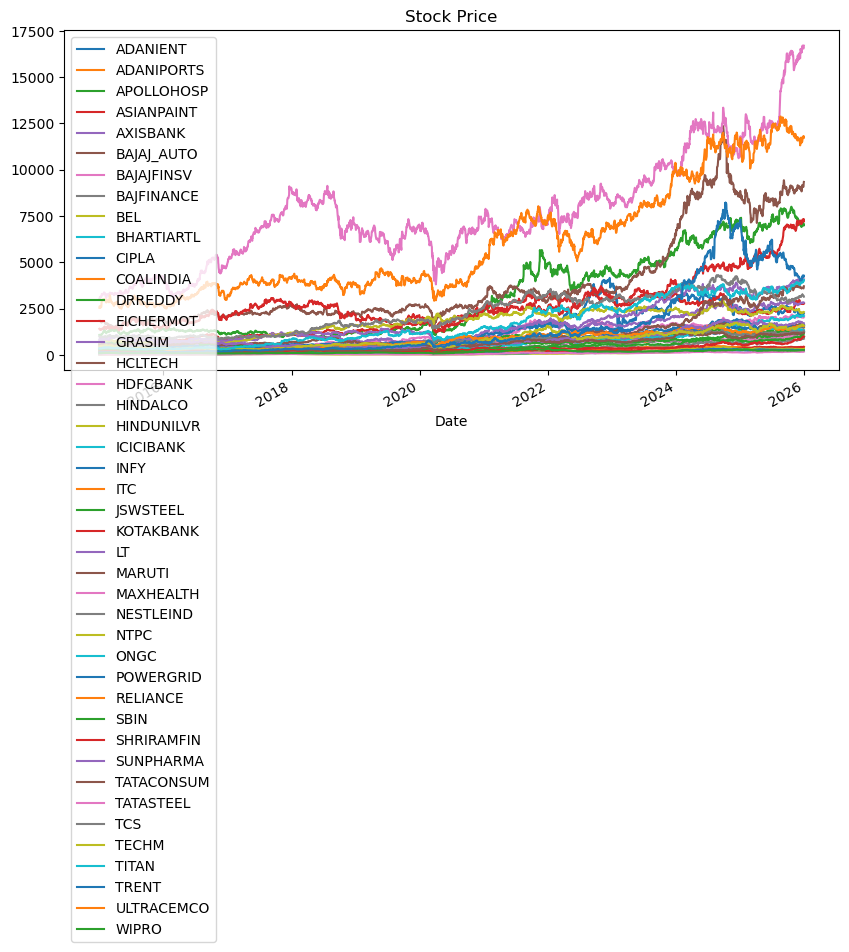

In [5]:
adj_close.plot(figsize=(10,5), title="Stock Price")

In [6]:
log_prices = np.log(adj_close)
log_prices

,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ_AUTO,BAJAJFINSV,BAJFINANCE,BEL,BHARTIARTL,...,SHRIRAMFIN,SUNPHARMA,TATACONSUM,TATASTEEL,TCS,TECHM,TITAN,TRENT,ULTRACEMCO,WIPRO
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-01,4.259313,5.709675,6.987252,6.529319,6.188188,7.520429,4.851277,3.519221,3.196753,5.730339,...,5.222233,6.623985,4.887741,3.363773,6.896572,6.136926,5.893641,4.967468,7.843075,4.512559
2015-01-02,4.264199,5.709049,6.988982,6.563307,6.210305,7.520266,4.842730,3.503105,3.191739,5.736246,...,5.225629,6.628899,4.899615,3.379230,6.909802,6.141809,5.901509,4.958629,7.872534,4.521391
2015-01-05,4.280615,5.722887,6.992302,6.563243,6.216604,7.523910,4.829354,3.500488,3.172667,5.713807,...,5.193942,6.629503,4.902561,3.393612,6.894489,6.124984,5.909575,4.959785,7.874574,4.523183
2015-01-06,4.272995,5.716846,6.962068,6.539082,6.180205,7.516077,4.805963,3.497893,3.159353,5.705932,...,5.169236,6.607244,4.870676,3.343921,6.856925,6.114199,5.874771,4.945653,7.846113,4.499531
2015-01-07,4.264098,5.714514,6.969871,6.558976,6.179403,7.518409,4.805109,3.518049,3.285769,5.708329,...,5.164009,6.608788,4.872698,3.324567,6.845043,6.109516,5.879856,4.971271,7.842155,4.491891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,7.706478,7.309413,8.876613,7.932183,7.111757,9.123693,7.618595,6.919387,5.987216,7.660915,...,6.881103,7.453440,7.072591,5.136210,8.089403,7.397255,8.271114,8.363949,9.372799,5.565721
2025-12-26,7.709712,7.304583,8.874380,7.918083,7.113305,9.112121,7.609664,6.907755,5.983334,7.652261,...,6.867194,7.443314,7.069619,5.130608,8.077583,7.385417,8.292048,8.362946,9.375346,5.559134
2025-12-29,7.697666,7.282349,8.864338,7.928550,7.116394,9.114600,7.606934,6.905753,5.970197,7.640892,...,6.862235,7.441975,7.086069,5.149237,8.068856,7.385479,8.289966,8.349011,9.375770,5.551368


<Axes: title={'center': 'Log Prices'}, xlabel='Date'>

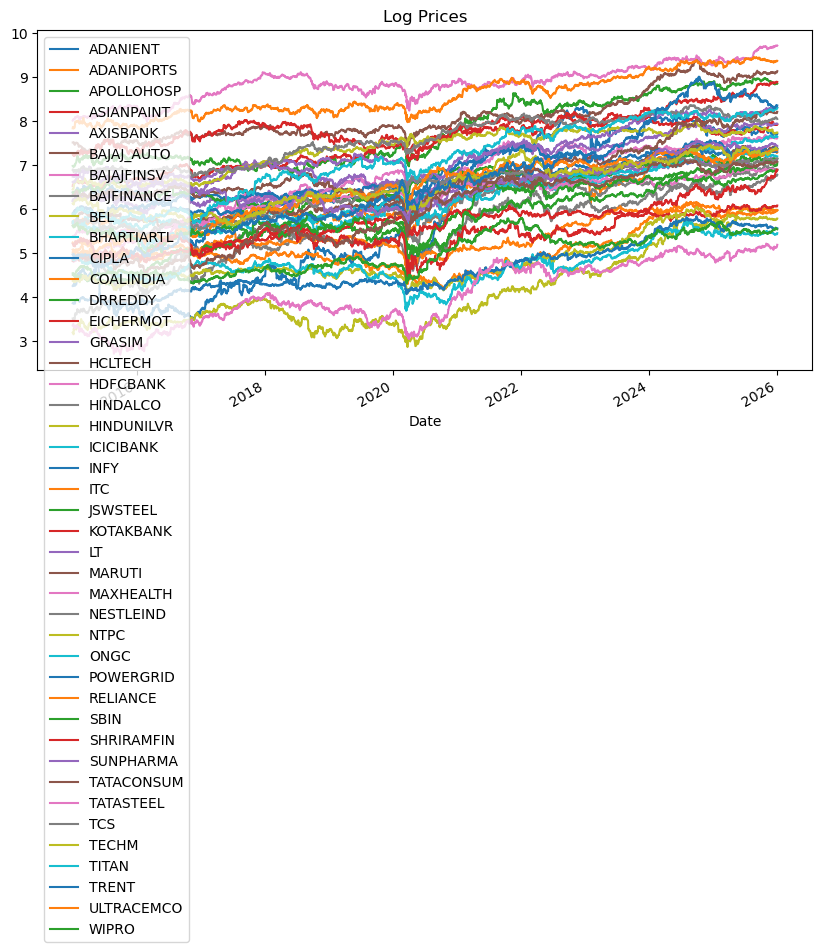

In [7]:
log_prices.plot(figsize=(10,5), title="Log Prices")

In [8]:
returns = log_prices.diff()
returns.dropna(inplace=True)

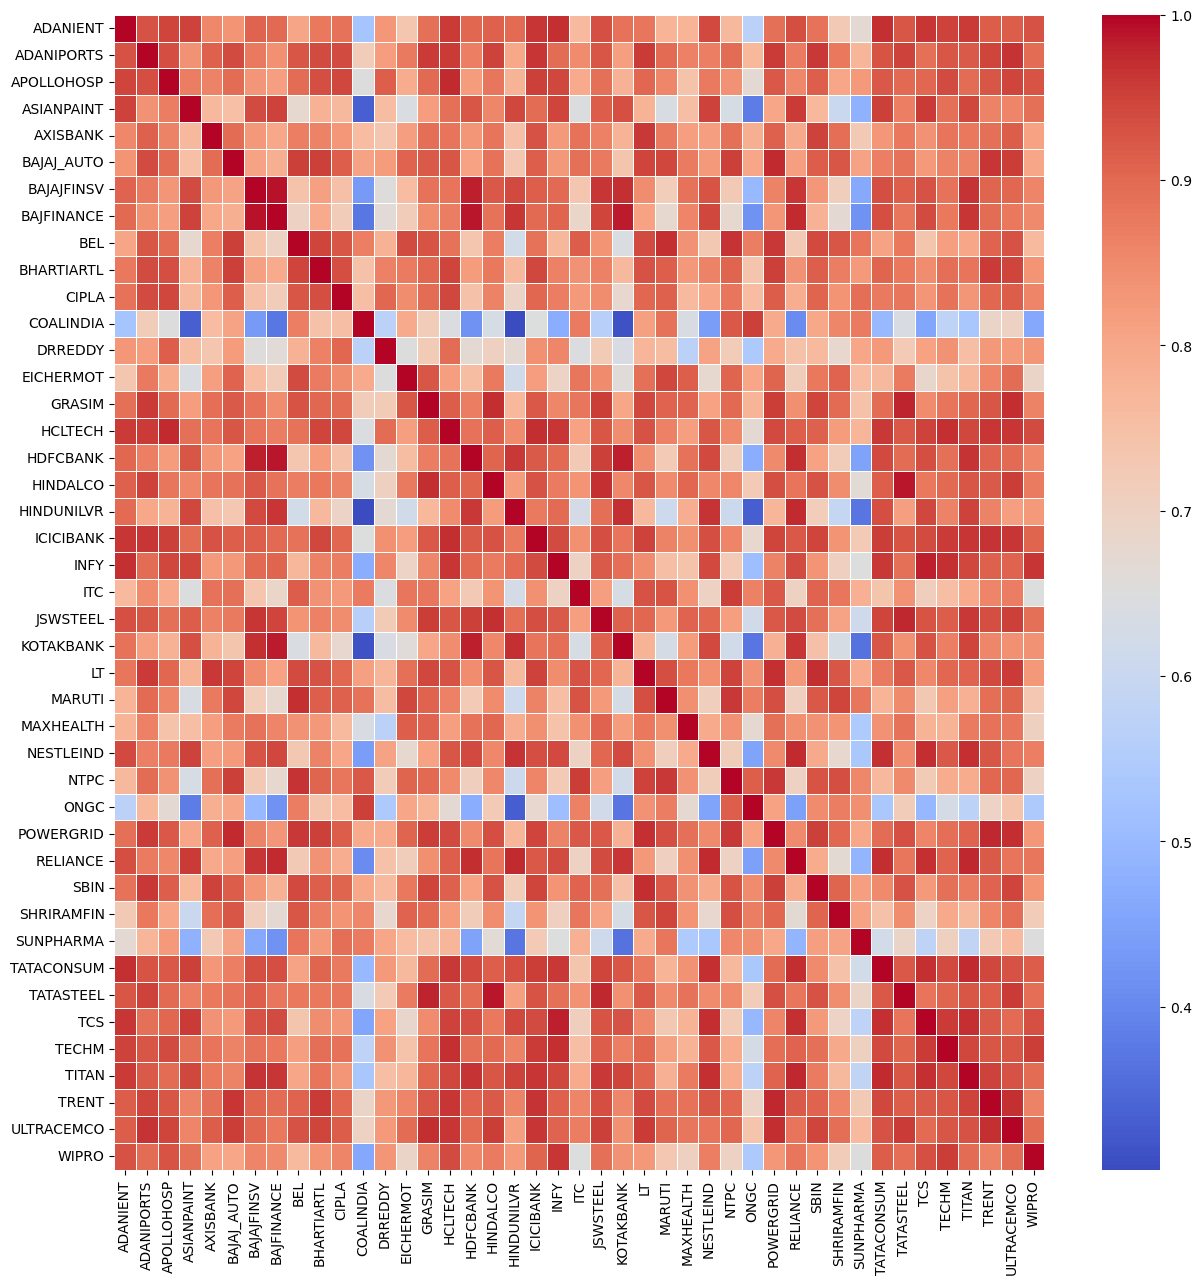

In [9]:
corr_matrix = log_prices.corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            linewidths=0.5)
plt.show()

<Axes: title={'center': 'Returns'}, xlabel='Date'>

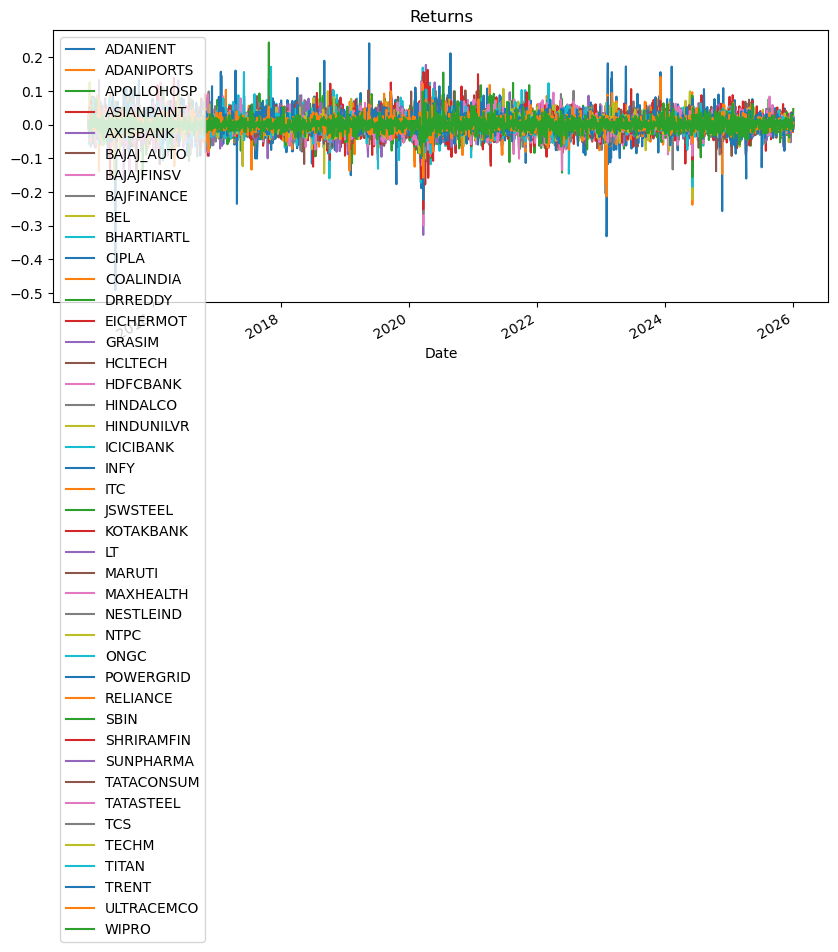

In [10]:
returns.plot(figsize=(10,4), title="Returns")

In [11]:
coint_pairs = {}

for i in log_prices.columns:
    for j in log_prices.columns:
        if i==j:
            continue
        pvalue = coint(log_prices[i], log_prices[j])[1]
        if pvalue < 0.05:
            print(i, j, pvalue)
            coint_pairs[(i+j)] = pvalue

ADANIENT INFY 0.020309672869784606
ADANIPORTS AXISBANK 0.025217407878796987
ADANIPORTS CIPLA 0.03794294581068765
ADANIPORTS GRASIM 0.019573483629183003
ADANIPORTS HCLTECH 0.010153165584552393
ADANIPORTS HINDALCO 0.039130418986109555
ADANIPORTS ICICIBANK 0.04238969185869286
ADANIPORTS POWERGRID 0.04234190325456746
ADANIPORTS SBIN 0.005761034808310251
ADANIPORTS ULTRACEMCO 0.0014350882766102368
APOLLOHOSP HCLTECH 0.017217829856003647
ASIANPAINT TCS 0.03219175814896218
AXISBANK ADANIPORTS 0.013229761009777755
AXISBANK BAJAJ_AUTO 0.034115163768137884
AXISBANK HCLTECH 0.02853868462079543
AXISBANK ICICIBANK 0.04077849574179572
AXISBANK ITC 0.024090099774598268
AXISBANK LT 0.00018314533962800165
AXISBANK NTPC 0.04044614963468844
AXISBANK POWERGRID 0.013506470326620005
AXISBANK SBIN 0.0009711723818116923
AXISBANK TECHM 0.03849018592200365
AXISBANK TRENT 0.04951692257944715
AXISBANK ULTRACEMCO 0.011122976673391715
BAJAJ_AUTO POWERGRID 0.012453010121722816
BAJAJ_AUTO SHRIRAMFIN 0.048092415274749

In [12]:
coint_pairs["KOTAKBANKHDFCBANK"]

0.00044075339385667324

<Axes: title={'center': 'Log Prices'}, xlabel='Date'>

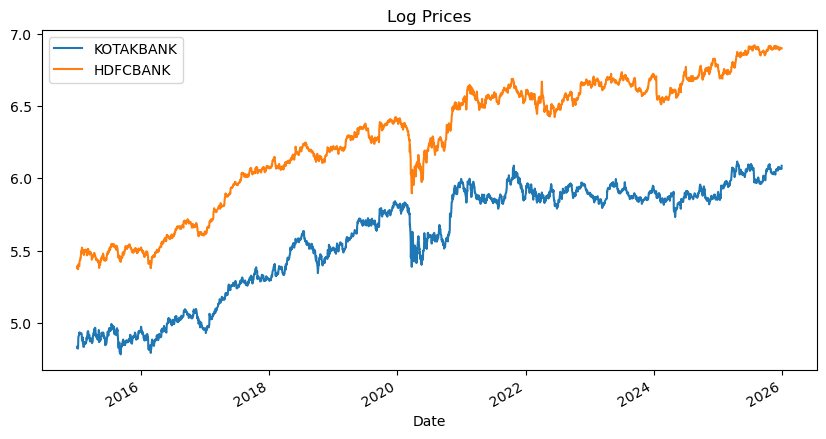

In [22]:
log_prices[["KOTAKBANK", "HDFCBANK"]].plot(figsize=(10,5), title="Log Prices")